# Introduction 

The goal is to develop a deep learning model that can accurately classify facial expressions into one of seven categories: Angry, Disgust, Fear, Happy, Sad, Surprise, and Neutral. I try a CNN model with a VGG-like structure to train the model with the FER2013 dataset

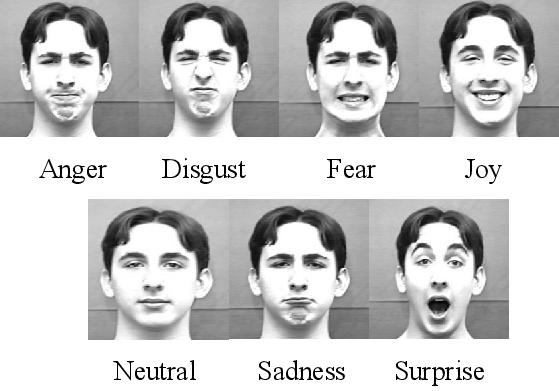



# Data

The FER-2013 dataset consists of 48x48 pixel grayscale images of faces that have been automatically registered to be centred and occupy a similar amount of space in each image. The dataset contains 24,400 images, with 22,968 examples in the training set and 1,432 examples in the public test set.

# Preprocessing

In this section, I will be using both data generators and data augmentation to train a deep learning model for human emotion detection using the FER-2013 dataset. 

Data generators create batches of images on-the-fly during training, making it possible to handle this large and complex dataset efficiently. Since loading all images into memory at once would be impractical, data generators allow the model to be trained on the entire dataset without exceeding memory limits.

Data augmentation techniques to the training images, such as rotation, shifting, and flipping for increasing the size and diversity of the training set, which can improve the performance of the deep learning model. By introducing variability into the training process, data augmentation can also help to prevent overfitting, which occurs when the model becomes too closely tailored to the training set and performs poorly on new, unseen data

In [16]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [17]:
train_dir = "/Users/bernardoquindimil/Code/Berniquindimil/Proyect/FER-2013/train" # Directory containing the training data
test_dir = "/Users/bernardoquindimil/Code/Berniquindimil/Proyect/FER-2013/test"  # Directory containing the validation data

In [18]:
train_datagen = ImageDataGenerator(
    width_shift_range = 0.1,        # Randomly shift the width of images by up to 10%
    height_shift_range = 0.1,       # Randomly shift the height of images by up to 10%
    horizontal_flip = True,         # Flip images horizontally at random
    rescale = 1./255,               # Rescale pixel values to be between 0 and 1
    validation_split = 0.2          # Set aside 20% of the data for validation
)

validation_datagen = ImageDataGenerator(
    rescale = 1./255,               # Rescale pixel values to be between 0 and 1
    validation_split = 0.2          # Set aside 20% of the data for validation
)

In [19]:
train_generator = train_datagen.flow_from_directory(
    directory = train_dir,           # Directory containing the training data
    target_size = (48, 48),          # Resizes all images to 48x48 pixels
    batch_size = 64,                 # Number of images per batch
    color_mode = "grayscale",        # Converts the images to grayscale
    class_mode = "categorical",      # Classifies the images into 7 categories
    subset = "training"              # Uses the training subset of the data
)

validation_generator = validation_datagen.flow_from_directory(
    directory = test_dir,            # Directory containing the validation data
    target_size = (48, 48),          # Resizes all images to 48x48 pixels
    batch_size = 64,                 # Number of images per batch
    color_mode = "grayscale",        # Converts the images to grayscale
    class_mode = "categorical",      # Classifies the images into 7 categories
    subset = "validation"            # Uses the validation subset of the data
)

Found 22968 images belonging to 7 classes.
Found 1432 images belonging to 7 classes.


# Modeling 

## CNN Model

To develop the CNN, at first I defined the the input layer and the number of filters in the first convolutional layer. Then, I added additional convolutional layers with increasing numbers of filters, followed by max-pooling layers to reduce the spatial dimensions of the feature maps. After the convolutional layers, I added fully connected layers with ReLU activation to classify the emotions.

I experimented with different numbers of convolutional layers, filter sizes, and fully connected layers to optimize the model performance. Additionally, I used techniques such as dropout and batch normalization to prevent overfitting and improve the generalization capability of the model.

In [20]:
from CNN_model import model
from tensorflow.keras.callbacks import ModelCheckpoint

# Define the callback
checkpoint_callback = ModelCheckpoint(
    filepath='model_weights.weights.h5',
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=True,
    mode='max',
    verbose=1
)

# Train the model with the callback
history = model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=60,
    validation_data=validation_generator,
    validation_steps=len(validation_generator),
    callbacks=[checkpoint_callback]
)

Epoch 1/60
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step - accuracy: 0.2742 - loss: 2.1251
Epoch 1: val_accuracy improved from -inf to 0.37360, saving model to model_weights.weights.h5
359/359 ━━━━━━━━━━━━━━━━━━━━ 114s 319ms/step - accuracy: 0.2742 - loss: 2.1250 - val_accuracy: 0.3736 - val_loss: 1.6370
Epoch 2/60
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step - accuracy: 0.2903 - loss: 2.0305
Epoch 2: val_accuracy improved from 0.37360 to 0.39944, saving model to model_weights.weights.h5
359/359 ━━━━━━━━━━━━━━━━━━━━ 114s 316ms/step - accuracy: 0.2903 - loss: 2.0304 - val_accuracy: 0.3994 - val_loss: 1.5923
Epoch 3/60
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step - accuracy: 0.3171 - loss: 1.9332
Epoch 3: val_accuracy did not improve from 0.39944
359/359 ━━━━━━━━━━━━━━━━━━━━ 115s 320ms/step - accuracy: 0.3171 - loss: 1.9332 - val_accuracy: 0.3994 - val_loss: 1.6079
Epoch 4/60
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step - accuracy: 0.3405 - loss: 1.8448
Epoch 4: val_accuracy improved from 0.39944

## Evaluation

### Training and validation loss curves

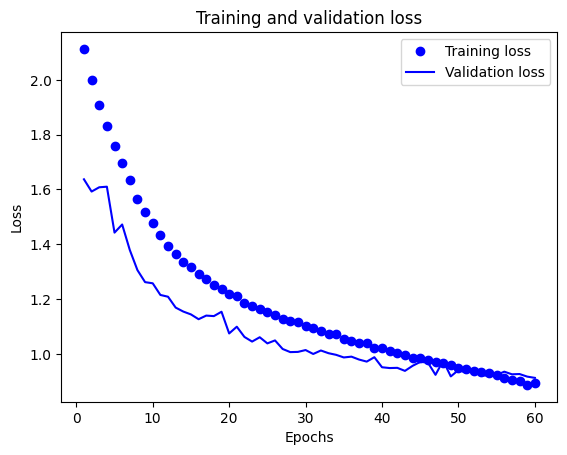

In [21]:
import matplotlib.pyplot as plt

# Plot the train and validation loss
train_loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(train_loss) + 1)
plt.plot(epochs, train_loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

### Training and validation accuracy curves

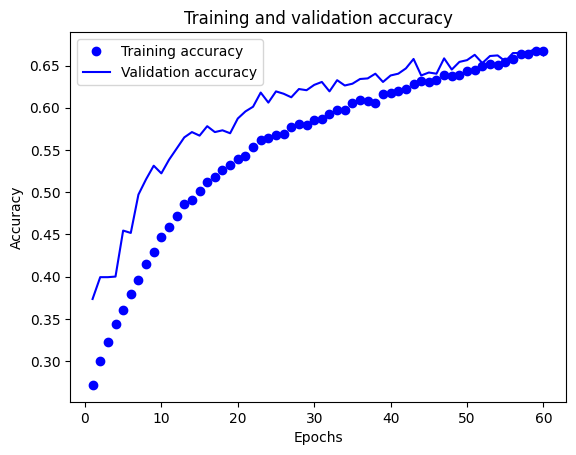

In [23]:
# Plot the train and validation accuracy
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
plt.plot(epochs, train_acc, 'bo', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

### Confusion Matrix

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step


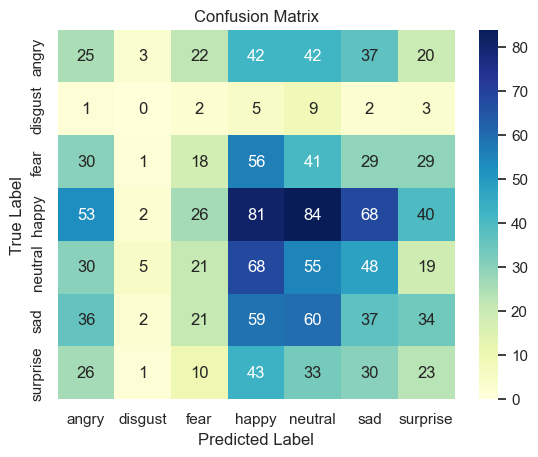

In [24]:
import seaborn as sns 
from sklearn.metrics import confusion_matrix
import numpy as np

# Get the true labels and predicted labels for the validation set
validation_labels = validation_generator.classes
validation_pred_probs = model.predict(validation_generator)
validation_pred_labels = np.argmax(validation_pred_probs, axis=1)

# Compute the confusion matrix
confusion_mtx = confusion_matrix(validation_labels, validation_pred_labels)
class_names = list(train_generator.class_indices.keys())
sns.set()
sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='YlGnBu', 
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()